# Weather Classification Technical Report
CPSC-322 Data Science | Fall 2025 | Written by Aiden Tabrah & Valon Haslem

### Introduction


#### 1) Overview:
[Weather Category Dataset](https://www.kaggle.com/datasets/muthuj7/weather-dataset) is a .csv file with 96.5k instances and 12 attributes. The attribute being selected for classification is the "summary" attribute, which weather predictors use to classify weather conditions in short descriptions.

#### 2) Description:
We will be using 10 non-classification attributes for training our classifiers, out of the 12. The layoyut of the dataset is as follows:  
  
**Summary**                     - Various classification labels such as "Partly Cloudy" or "Mostly Cloudy"   
 ___
**Date**                 - Dates from 2005 to 2016  
**Precip-type**               - rain, snow, or other   
**Temperature (C)**                 - Temperature in celsius from -21.8 to 39.9  
**Apparent Temperature (C)**                   -  How it "feels" outside due to wind or other conditions. Ranges from -27.7 to 39.3  
**Humidity**                      - Percentage between 0.00 and 1.00  
**Wind Speed (km/h)**           - Wind speed in kilometers per hour, from 0 to 63.9  
**Wind Bearing (degrees)**              - Wind direction from 0 to 359  
**Visibility (km)**                 - How far one should be able to see, in kilometers.  
**Pressure (millibars)**               - Pressure from 0 to 1.05k  
**Loud Cover** - Potentially cloud cover? All data values are 0.0 though. (Will not be used)  
**Daily Summary** - A more descriptive classification of the data, that isn't standardized and varies more often. (Will not be used)


#### 3) Findings:
TODO: [Insert summary of findings]

#### Imports

In [1]:
from tabulate import tabulate
import importlib

import mysklearn.myutils
importlib.reload(mysklearn.myutils)
import mysklearn.myutils as myutils

import mysklearn.mypytable
importlib.reload(mysklearn.mypytable)
from mysklearn.mypytable import MyPyTable 

import mysklearn.myclassifiers
importlib.reload(mysklearn.myclassifiers)
from mysklearn.myclassifiers import MyDecisionTreeClassifier

import mysklearn.myevaluation
importlib.reload(mysklearn.myevaluation)
import mysklearn.myevaluation as myevaluation

# Constants:
k = 10
seed = 1

#### Data Cleaning / Setup

There were a couple attributes that needed cleaning, and we used these strategies for the following attribtues:
- Pressure - 0.0 pressure is not a legitimate value, and we replaced those invalid values with the mean pressure of the dataset.
- Missing values - any instance with a missing value is removed from the dataset.
- Date - needs to be turned into a continuous attribute rather than categorical for analysis with the rest of the attributes.
- Precip-type - This is a very strong predictor, so we should keep this.
- All attributes - all remaining attributes besides the classification are continuous. They should be normalized.

In [2]:

weather_data = MyPyTable().load_from_file("input-data/weatherHistory.csv")
weather_data.remove_rows_with_missing_values()
weather_data.save_to_file("output-data/weatherHistory_cleaned.csv")

weather_data.replace_column("Formatted Date", myutils.convert_date_to_numeric(weather_data.get_column("Formatted Date")))
# replace pressure zero values with mean

weather_data.replace_column('Pressure (millibars)', myutils.convert_zeros_to_mean(weather_data.get_column('Pressure (millibars)')))
weather_data.normalize_values(["Formatted Date", "Temperature (C)","Apparent Temperature (C)",
                               "Humidity", "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"])

weather_data.save_to_file("output-data/weatherHistory_normalized_and_cleaned.csv")

#### Loading data

In [3]:
weather_data = MyPyTable().load_from_file("output-data/weatherHistory_normalized_and_cleaned.csv")

all_ys = [val[0] for val in weather_data.select_columns(["Summary"]).data]
weather_x_data = weather_data.select_columns(["Formatted Date", "Temperature (C)", "Apparent Temperature (C)",
                                      "Humidity", "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"])
all_xs = weather_x_data.data


Should we use the boxplots to determine our discretizer? we could just discretize by mean (high low) or also use first and third quadrants. will probably need to explain our decisions in the presentation.

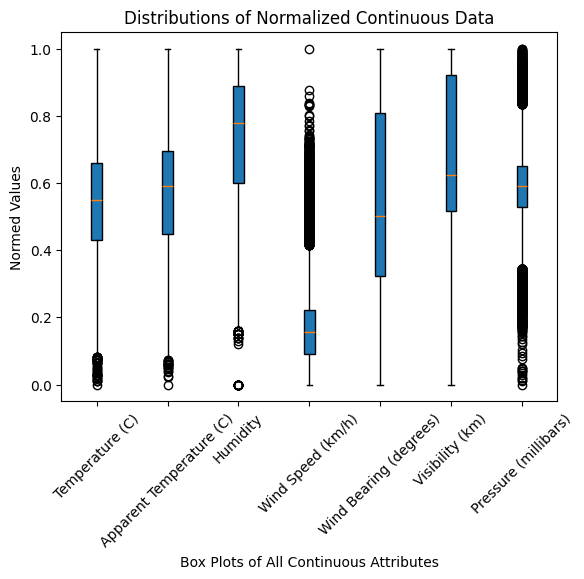

In [5]:
# box plots for continuous data
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
weather_cts_data = weather_data.select_columns(["Temperature (C)", "Apparent Temperature (C)",
                                      "Humidity", "Wind Speed (km/h)", "Wind Bearing (degrees)", "Visibility (km)", "Pressure (millibars)"]).data
weather_cts_data_transposed = [list(row) for row in zip(*weather_cts_data)]

for idx, data in enumerate(weather_cts_data_transposed):
    # first, normalize it
    new_data = myutils.norm_list(data)
    ax.boxplot(new_data, positions = [idx], patch_artist=True)


ax.set_xticks(range(len(weather_cts_data_transposed)))
ax.set_xticklabels(["Temperature (C)", 
                    "Apparent Temperature (C)",
                    "Humidity", 
                    "Wind Speed (km/h)", 
                    "Wind Bearing (degrees)", 
                    "Visibility (km)", 
                    "Pressure (millibars)"])
plt.xticks(rotation = 45)
ax.set_title("Distributions of Normalized Continuous Data")
ax.set_ylabel('Normed Values')
ax.set_xlabel('Box Plots of All Continuous Attributes')
plt.show()


#### Discretize each continuous row.
Use mean or median based on whether outliers exist, since outliers have a pronounced effect on the mean and don't really affect the median.

In [6]:

weather_disc_data = [weather_data.get_column('Formatted Date')] # we leave this as a col identifier (or just remove?)
# mean for wind bearing and vis (4 and 5) but median for all else
for i in range(7):
    crit_bool = True
    new_col = [float(weather_cts_data_transposed[i][j]) for j in range(len(weather_cts_data_transposed[0]))] # need to fix datatype
    if i == 4 or i == 5:
        crit_bool = True
    else: 
        crit_bool = False
    weather_disc_data.append([myutils.high_low_discretizer(new_col, crit_bool)])
weather_disc_data.append(all_ys)
# transpose back to normal NOTE: not normalized yet
disc_prepped_weather = [list(row) for row in zip(*weather_disc_data)]


#### Comparing Classifiers
Decision Tree - Need to discretize continuous classifiers for this to work.
Knn - should be very simple since everything is already normalized.
Naive Bayes - also need to do some discretizing.

Set of possible cols: {'Humid and Partly Cloudy', 'Breezy and Mostly Cloudy', 'Light Rain', 'Dry', 'Foggy', 'Windy and Mostly Cloudy', 'Breezy and Foggy', 'Partly Cloudy', 'Humid and Mostly Cloudy', 'Mostly Cloudy', 'Windy and Overcast', 'Windy and Foggy', 'Windy', 'Breezy', 'Humid and Overcast', 'Dry and Mostly Cloudy', 'Clear', 'Drizzle', 'Dangerously Windy and Partly Cloudy', 'Breezy and Dry', 'Overcast', 'Windy and Partly Cloudy', 'Dry and Partly Cloudy', 'Breezy and Partly Cloudy', 'Breezy and Overcast', 'Windy and Dry', 'Rain'}

In addition, histogram shows that some values are significantly more frequent than others, so we will have significant issues with data distributions -- fix histogram make legible

In [ ]:

summary_col = weather_data.get_column('Summary')
import matplotlib.pyplot as plt




plt.figure(figsize=(12,6))
plt.hist(x = summary_col, density=True, rwidth = .2, histtype = 'barstacked')
plt.title('Distribution of Summary')
plt.xlabel('Different Summary Values')
plt.ylabel('Proportion of Data')
plt.tight_layout()
plt.xticks(rotation = 45, fontsize = 10)
plt.show()


#### Random Forest

Probably want stratified k fold cross validation, although some summaries happen so rarely that it might not be useful.

In [7]:
from mysklearn.myclassifiers import MyRandomForestClassifier
# hyperparameters N, M, F dont forget to tune
randomforest = MyRandomForestClassifier(10, 3, 2)

# X_train, X_test, y_train, y_test = myevaluation.train_test_split(X = all_xs, y = all_ys)

# fit
X_train_iphone = [
        [1, 3, "fair"], # no
        [1, 3, "excellent"], # no
        [2, 3, "fair"],# yes
        [2, 2, "fair"], #yes
        [2, 1, "fair"],# yes
        [2, 1, "excellent"],# no
        [2, 1, "excellent"], #yes
        [1, 2, "fair"], # no
        [1, 1, "fair"], # yes
        [2, 2, "fair"], # yes
        [1, 2, "excellent"], # yes
        [2, 2, "excellent"], # yes
        [2, 3, "fair"], # yes
        [2, 2, "excellent"], # no
        [2, 3, "fair"] #yes
    ]
y_train_iphone = ["no", "no", "yes", "yes", "yes", "no", "yes", "no", "yes", "yes", "yes", "yes", "yes", "no", "yes"]


X_test_iphone = [[2, 2, 'fair'], [1, 1, 'excellent']]
y_test_iphone = ['yes', 'yes']
randomforest.fit(X= X_train_iphone, y = y_train_iphone)
# predict
y_preds = randomforest.predict(X_test = X_test_iphone)

# acc score
acc = myevaluation.accuracy_score(y_true=y_test_iphone, y_pred = y_preds)
print(f'Accuracy is {round(acc, 2)}')


['yes', 'no', 'yes', 'yes', 'no', 'yes', 'yes', 'yes', 'yes', 'no', 'yes', 'yes', 'yes', 'no', 'yes']
['yes', 'yes', 'yes', 'yes', 'no', 'no', 'yes', 'yes', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes']
['yes', 'yes', 'yes', 'yes', 'yes', 'no', 'yes', 'yes', 'yes', 'yes', 'no', 'no', 'yes', 'yes', 'no']
['no', 'yes', 'no', 'no', 'yes', 'no', 'yes', 'no', 'no', 'yes', 'no', 'no', 'no', 'yes', 'no']
['no', 'yes', 'yes', 'yes', 'yes', 'no', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'no', 'no']
['no', 'yes', 'no', 'yes', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'no', 'no', 'no', 'no', 'no']
['yes', 'no', 'yes', 'yes', 'no', 'yes', 'yes', 'yes', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no']
['yes', 'yes', 'yes', 'no', 'no', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no', 'yes', 'yes', 'no']
['yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'no', 'yes', 'yes', 'no', 'yes', 'yes']
['yes', 'yes', 'yes', 'yes', 'no', 'yes', 'yes', 'no', 'yes', 'yes', 'no', 'yes', 'yes', 'yes', '

#### Decision Tree

#### kNN